<a href="https://colab.research.google.com/github/Vaishnavi200527/RollNo_39_MLDL_Lab/blob/main/EXP8_MLDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Import Libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
# Step 2: Load Dataset (MNIST)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


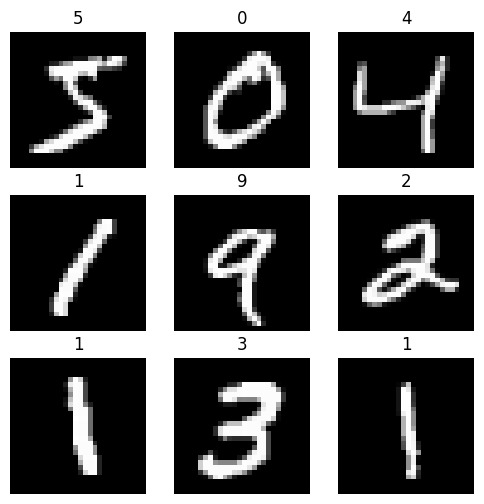

In [11]:
# Step 3: Preprocessing
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.show()

In [12]:
# Step 4: Preprocessing
X_train = X_train / 255.0
X_test = X_test / 255.0

In [13]:
# Reshape for CNN
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [14]:
# Step 5: Build CNN Model
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [16]:
# Step 6: Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [18]:
# Step 7: Train Model
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.7726 - loss: 0.6931 - val_accuracy: 0.9055 - val_loss: 0.3072
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 34ms/step - accuracy: 0.9245 - loss: 0.2528 - val_accuracy: 0.9485 - val_loss: 0.1761
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9532 - loss: 0.1550 - val_accuracy: 0.9654 - val_loss: 0.1120
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9652 - loss: 0.1120 - val_accuracy: 0.9695 - val_loss: 0.0976
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.9717 - loss: 0.0902 - val_accuracy: 0.9770 - val_loss: 0.0753


In [20]:
# Step 8: Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9770 - loss: 0.0753
Accuracy: 0.9769999980926514


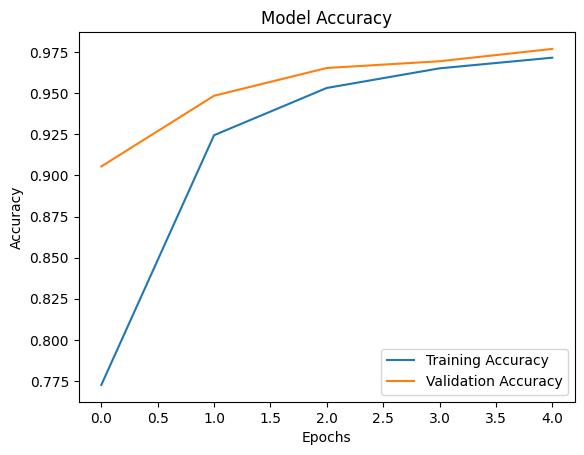

In [21]:
# Step 9: Plot Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

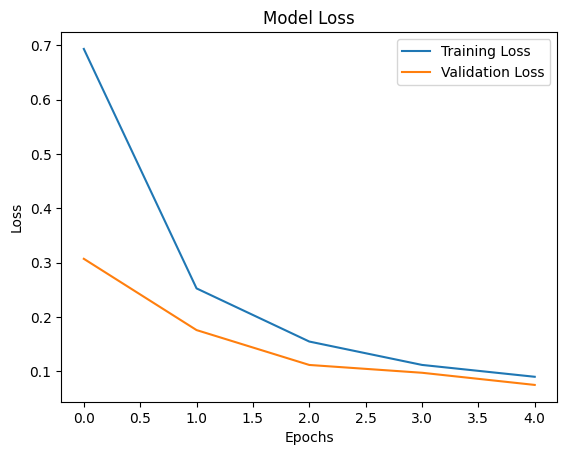

In [22]:
# Step 10: Plot Loss Graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])

plt.show()